# Model Development, Evaluation, and Explainability (Objectives 2–4)

**Module:** IT41012 Research Methodology  
**Inputs:** prepared datasets from notebook 01 (`Data/processed/`)  
**Scope:** supervised risk classification (Low / Moderate / High), nested CV comparison, SHAP + LIME on the best model per dataset.  
**Not in scope:** re-running EDA / feature prep.

## Locked protocol

| Item | Setting |
|------|---------|
| Holdout | Stratified 80/20 |
| Nested CV | Outer 5-fold × inner RandomizedSearchCV (5-fold, `n_iter=20`; SVM capped for tractability) |
| Imbalance | SMOTE inside `imblearn` pipeline (train folds only) |
| Scaling | `StandardScaler` for LR, SVM, MLP; none for RF / XGBoost |
| Selection metric | Macro-F1 (tie-break: ROC-AUC OvR macro) |
| Models | Logistic Regression, RBF-SVM, Random Forest, XGBoost, Neural Net (MLP) |
| XAI | SHAP (global) + LIME (one instance per class) on the winner per dataset |

Parts **A** and **B** apply the same protocol to Dataset 1 and Dataset 2.

## Setup

Import shared helpers from `src/modeling_core.py`, fix the random seed, and create output folders.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

# Project root whether CWD is repo root or notebooks/
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / "Data" / "processed").exists() else CWD.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.modeling_core import (
    INT_TO_LABEL,
    LABEL_ORDER,
    LABEL_TO_INT,
    N_ITER_SEARCH,
    RANDOM_SEED,
    classification_metrics,
    evaluate_holdout,
    load_prepared,
    plot_confusion,
    plot_roc_ovr,
    run_all_nested_cv,
    run_lime,
    run_shap,
    select_best_model,
    tune_and_fit_best,
)

RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")

print("PROJECT_ROOT =", PROJECT_ROOT)
print("N_ITER_SEARCH =", N_ITER_SEARCH)

PROJECT_ROOT = C:\Users\ishan\OneDrive\Documents\Work\3 Year 2 Semester\IT41012 - Research Methodology\Research Paper\reward-seeking-behavior-ml
N_ITER_SEARCH = 20


---
# Part A — Dataset 1 (Smartphone Usage & Addiction)

**Source:** `Data/processed/dataset1_prepared.csv`  
**Population:** young adults (ages 18–35 in source data)  
**Target:** `risk_level` ∈ {Low, Moderate, High}

## A1. Objective 2 — Load data and stratified split

**Decision:** 80/20 stratified holdout so class proportions are preserved in the final test set.  
**Assumption:** prepared features contain no leakage columns (validated in notebook 01).

In [2]:
path_d1 = PROJECT_ROOT / "Data" / "processed" / "dataset1_prepared.csv"
X1, y1, feats1 = load_prepared(path_d1)

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.20,
    stratify=y1,
    random_state=RANDOM_SEED,
)

print("Dataset 1 features:", feats1)
print("Train:", X1_train.shape, "Test:", X1_test.shape)
print("Train class counts:")
display(y1_train.map(INT_TO_LABEL).value_counts())
print("Test class counts:")
display(y1_test.map(INT_TO_LABEL).value_counts())

Dataset 1 features: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'stress_level_ord', 'gender_Male', 'gender_Other', 'reward_app_share']
Train: (6000, 12) Test: (1500, 12)
Train class counts:


risk_level
Moderate    2299
High        1947
Low         1754
Name: count, dtype: int64

Test class counts:


risk_level
Moderate    575
High        487
Low         438
Name: count, dtype: int64

## A2. Objective 2–3 — Nested CV model comparison

Each model is an `imblearn` pipeline: optional scaling → **SMOTE** → estimator.  
Inner search optimises **macro-F1**. Outer folds estimate generalisation without leaking the selected hyperparameters.

**SVM note:** RBF-SVM tuning on large outer-train folds uses a stratified subsample (≤2500) for the inner search, then the chosen hyperparameters are refit on the **full** outer-train fold before scoring the outer validation fold. Other models use the full fold. This keeps nested CV computationally tractable while preserving the protocol.

In [3]:
cv_summary_d1, cv_details_d1 = run_all_nested_cv(
    X1_train, y1_train, n_iter=N_ITER_SEARCH, random_state=RANDOM_SEED
)
display(cv_summary_d1)
cv_summary_d1.to_csv(RESULTS_DIR / "dataset1_model_comparison.csv", index=False)
print("Saved results/dataset1_model_comparison.csv")


=== Nested CV: LogisticRegression (n_iter=20) ===


  [LogisticRegression] outer fold 1/5: F1_macro=0.6192 Acc=0.6117


  [LogisticRegression] outer fold 2/5: F1_macro=0.5962 Acc=0.5867


  [LogisticRegression] outer fold 3/5: F1_macro=0.6127 Acc=0.6025


  [LogisticRegression] outer fold 4/5: F1_macro=0.6108 Acc=0.6042


...

  [NeuralNet] outer fold 3/5: F1_macro=0.5900 Acc=0.5833


  [NeuralNet] outer fold 4/5: F1_macro=0.5993 Acc=0.5992


  [NeuralNet] outer fold 5/5: F1_macro=0.5984 Acc=0.5892


,model,cv_f1_macro_mean,cv_f1_macro_std,cv_accuracy_mean,cv_accuracy_std,cv_roc_auc_mean,cv_roc_auc_std
3,XGBoost,0.631468,0.009198,0.618333,0.009037,0.814626,0.004268
2,RandomForest,0.627876,0.011540,0.618833,0.011038,0.812900,0.004033
0,LogisticRegression,0.607218,0.009019,0.598167,0.010212,0.799532,0.005238
4,NeuralNet,0.601600,0.010756,0.595167,0.010768,0.802428,0.004577
1,SVM,0.597967,0.008702,0.591167,0.013464,0.797939,0.009301


Saved results/dataset1_model_comparison.csv


## A3. Select best model, refit on train, evaluate holdout

**Selection rule:** highest outer-CV macro-F1; tie-break ROC-AUC OvR macro.

Best model (Dataset 1): XGBoost


Best params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Holdout metrics:


accuracy             0.622000
precision_macro      0.626791
recall_macro         0.644181
f1_macro             0.633228
f1_weighted          0.614860
roc_auc_ovr_macro    0.815798
dtype: float64

              precision    recall  f1-score   support

         Low      0.854     0.932     0.891       438
    Moderate      0.508     0.426     0.464       575
        High      0.519     0.575     0.545       487

    accuracy                          0.622      1500
   macro avg      0.627     0.644     0.633      1500
weighted avg      0.612     0.622     0.615      1500



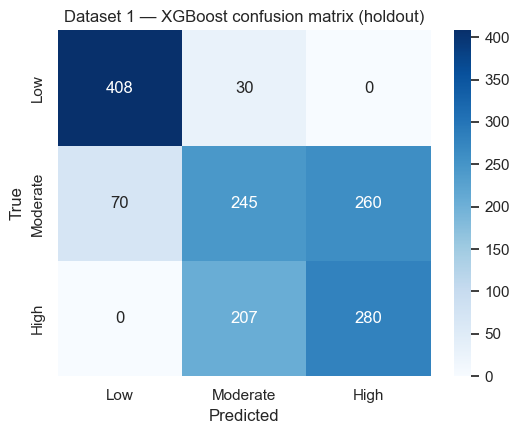

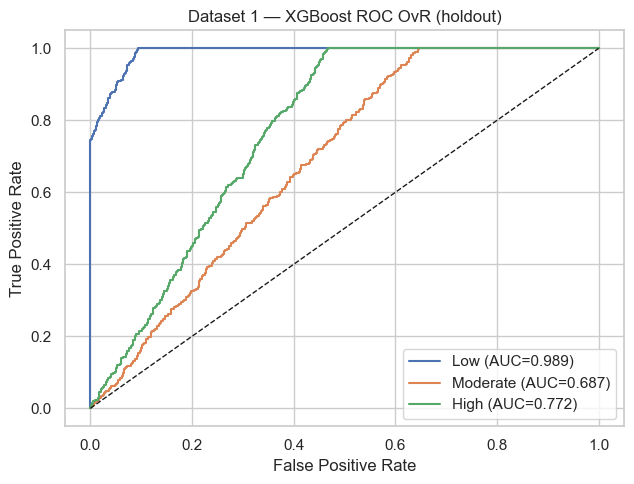

Saved model + metrics for Dataset 1


In [4]:
best_d1 = select_best_model(cv_summary_d1)
print("Best model (Dataset 1):", best_d1)

search_d1 = tune_and_fit_best(
    best_d1, X1_train, y1_train, n_iter=N_ITER_SEARCH, random_state=RANDOM_SEED
)
print("Best params:", search_d1.best_params_)

holdout_d1, pred_d1, proba_d1 = evaluate_holdout(search_d1.best_estimator_, X1_test, y1_test)
print("Holdout metrics:")
display(pd.Series(holdout_d1))

print(classification_report(
    y1_test, pred_d1, target_names=LABEL_ORDER, digits=3
))

plot_confusion(
    y1_test.values,
    pred_d1,
    f"Dataset 1 — {best_d1} confusion matrix (holdout)",
    FIG_DIR / "dataset1_confusion.png",
)
plot_roc_ovr(
    y1_test.values,
    proba_d1,
    f"Dataset 1 — {best_d1} ROC OvR (holdout)",
    FIG_DIR / "dataset1_roc_ovr.png",
)

joblib.dump(search_d1.best_estimator_, RESULTS_DIR / "dataset1_best_model.joblib")
payload_d1 = {
    "dataset": "dataset1",
    "best_model": best_d1,
    "best_params": search_d1.best_params_,
    "cv_summary": cv_summary_d1.to_dict(orient="records"),
    "holdout_metrics": holdout_d1,
    "features": feats1,
}
(RESULTS_DIR / "dataset1_metrics.json").write_text(
    json.dumps(payload_d1, indent=2, default=str), encoding="utf-8"
)
print("Saved model + metrics for Dataset 1")

## A4. Objective 4 — SHAP (global) and LIME (local)

**SHAP:** TreeExplainer for RF/XGBoost; LinearExplainer for LR; KernelExplainer (subsampled) for SVM/MLP.  
**LIME:** one Low / Moderate / High test instance (prefer correctly classified).  
**Interpretation focus:** which behavioural signals drive High-risk predictions (usage, notifications/app opens, sleep, stress).

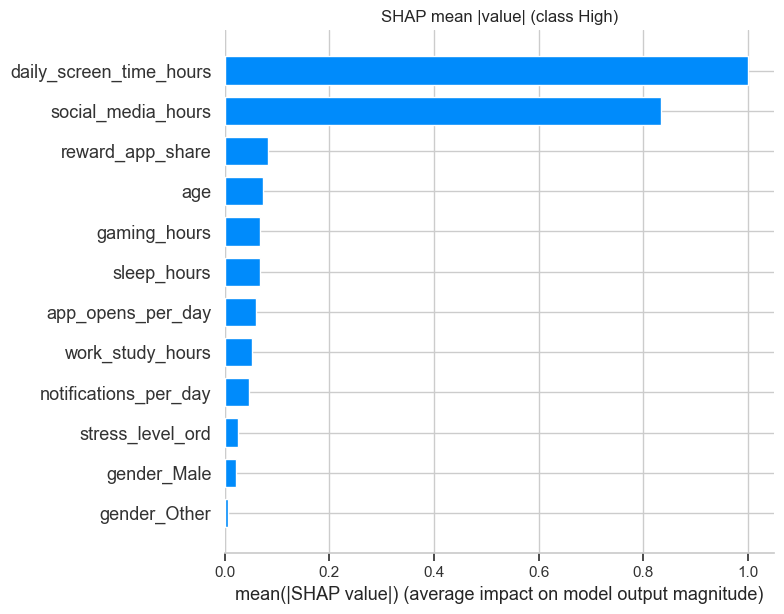

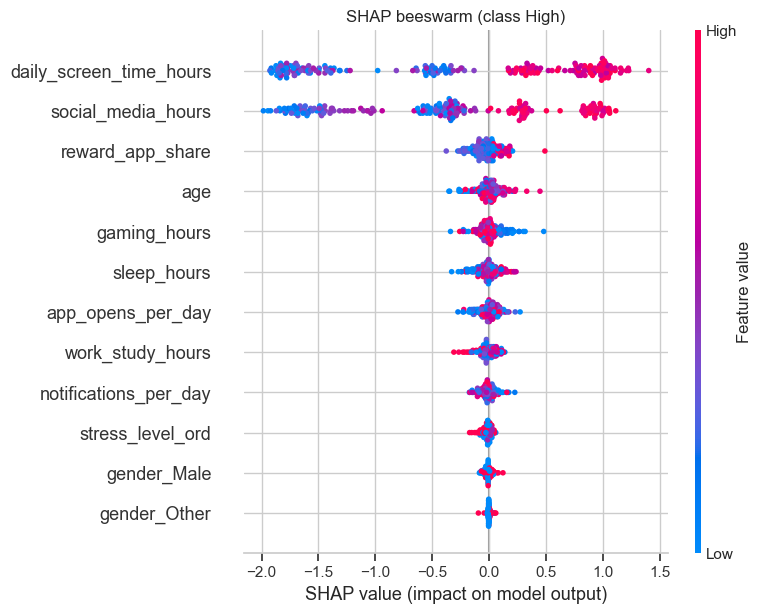

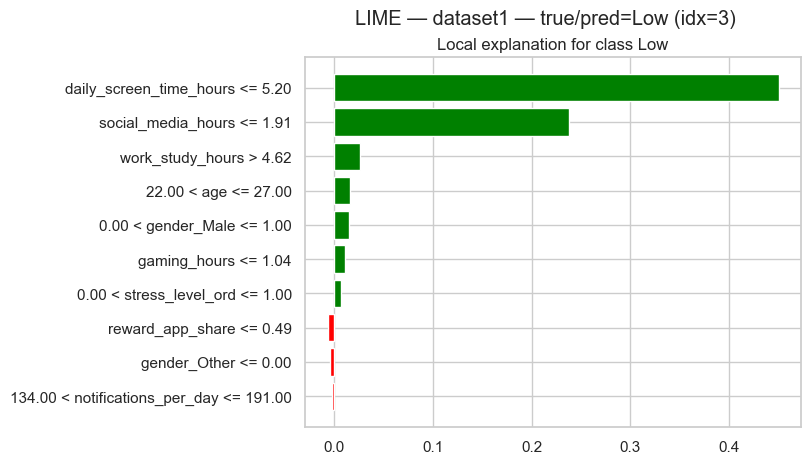

Saved LIME explanation: dataset1_lime_low.png


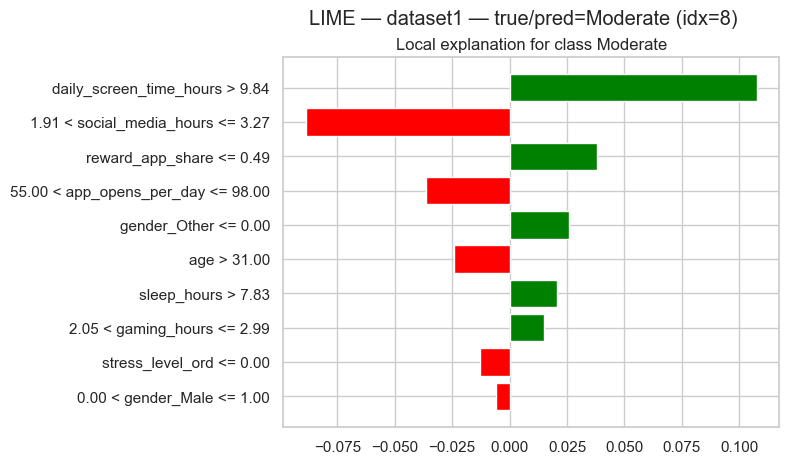

Saved LIME explanation: dataset1_lime_moderate.png


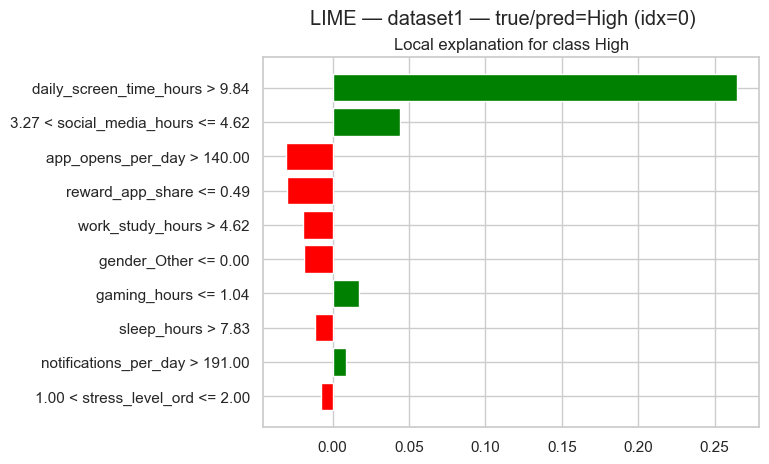

Saved LIME explanation: dataset1_lime_high.png


In [5]:
pipe_d1 = search_d1.best_estimator_
_ = run_shap(
    pipe_d1,
    best_d1,
    X1_train.values,
    X1_test.values,
    feats1,
    FIG_DIR / "dataset1",
    max_background=100,
    max_explain=200,
)

run_lime(
    pipe_d1,
    X1_train.values,
    X1_test.values,
    y1_test.values,
    pred_d1,
    feats1,
    FIG_DIR,
    dataset_tag="dataset1",
)

### Dataset 1 — XAI interpretation notes

- Inspect SHAP bar/beeswarm plots for **High** risk: features with largest mean |SHAP| are the primary global drivers (RQ2).
- LIME panels show instance-level evidence (e.g. high notification/app-open rates or low sleep pushing a single user toward High).
- Compare these drivers to the proposal feature groups (usage volume, interaction frequency, lifestyle).

---
# Part B — Dataset 2 (Mobile Addiction Data, ages 18–35)

**Source:** `Data/processed/dataset2_prepared.csv`  
**Notes:** smaller n after age filter; richer behavioural feature set; same 3-class target construction (High+Severe → High).

## B1. Load and stratified split

In [6]:
path_d2 = PROJECT_ROOT / "Data" / "processed" / "dataset2_prepared.csv"
X2, y2, feats2 = load_prepared(path_d2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    stratify=y2,
    random_state=RANDOM_SEED,
)

print("Dataset 2 features (n={}):".format(len(feats2)), feats2)
print("Train:", X2_train.shape, "Test:", X2_test.shape)
display(y2_train.map(INT_TO_LABEL).value_counts())
display(y2_test.map(INT_TO_LABEL).value_counts())

Dataset 2 features (n=25): ['Age', 'Income_USD', 'Daily_Screen_Time_Hours', 'Phone_Unlocks_Per_Day', 'Social_Media_Usage_Hours', 'Gaming_Usage_Hours', 'Streaming_Usage_Hours', 'Messaging_Usage_Hours', 'Work_Related_Usage_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Stress_Level', 'Time_Spent_With_Family_Hours', 'Online_Shopping_Hours', 'Has_Screen_Time_Management_App', 'Monthly_Data_Usage_GB', 'Has_Night_Mode_On', 'Age_First_Phone', 'Push_Notifications_Per_Day', 'Tech_Savviness_Score', 'Education_Level_ord', 'Gender_Male', 'Gender_Other', 'Urban_Urban', 'reward_app_share']
Train: (723, 25) Test: (181, 25)


risk_level
High        374
Moderate    177
Low         172
Name: count, dtype: int64

risk_level
High        94
Moderate    44
Low         43
Name: count, dtype: int64

## B2. Nested CV comparison

In [7]:
cv_summary_d2, cv_details_d2 = run_all_nested_cv(
    X2_train, y2_train, n_iter=N_ITER_SEARCH, random_state=RANDOM_SEED
)
display(cv_summary_d2)
cv_summary_d2.to_csv(RESULTS_DIR / "dataset2_model_comparison.csv", index=False)
print("Saved results/dataset2_model_comparison.csv")


=== Nested CV: LogisticRegression (n_iter=20) ===


  [LogisticRegression] outer fold 1/5: F1_macro=0.3104 Acc=0.3172


  [LogisticRegression] outer fold 2/5: F1_macro=0.3263 Acc=0.3310


  [LogisticRegression] outer fold 3/5: F1_macro=0.3476 Acc=0.3655


  [LogisticRegression] outer fold 4/5: F1_macro=0.3295 Acc=0.3681


...

  [NeuralNet] outer fold 3/5: F1_macro=0.3173 Acc=0.3517


  [NeuralNet] outer fold 4/5: F1_macro=0.3278 Acc=0.3333


  [NeuralNet] outer fold 5/5: F1_macro=0.3372 Acc=0.3542


,model,cv_f1_macro_mean,cv_f1_macro_std,cv_accuracy_mean,cv_accuracy_std,cv_roc_auc_mean,cv_roc_auc_std
3,XGBoost,0.333320,0.025253,0.438429,0.024953,0.490871,0.039600
1,SVM,0.325931,0.034219,0.372069,0.058623,0.520097,0.024959
0,LogisticRegression,0.325169,0.013533,0.341648,0.021016,0.480178,0.011013
4,NeuralNet,0.320212,0.010906,0.354052,0.011812,0.496618,0.016500
2,RandomForest,0.318965,0.030776,0.449502,0.027324,0.483238,0.037906


Saved results/dataset2_model_comparison.csv


## B3. Best model holdout evaluation

Best model (Dataset 2): XGBoost


Best params: {'model__subsample': 0.85, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.85}
Holdout metrics:


accuracy             0.408840
precision_macro      0.308179
recall_macro         0.315678
f1_macro             0.307359
f1_weighted          0.383899
roc_auc_ovr_macro    0.518988
dtype: float64

              precision    recall  f1-score   support

         Low      0.156     0.116     0.133        43
    Moderate      0.242     0.182     0.208        44
        High      0.526     0.649     0.581        94

    accuracy                          0.409       181
   macro avg      0.308     0.316     0.307       181
weighted avg      0.369     0.409     0.384       181



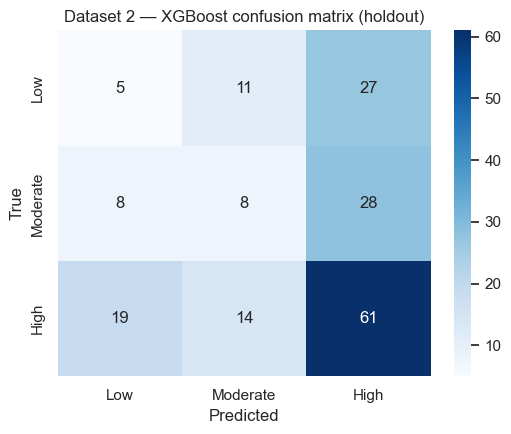

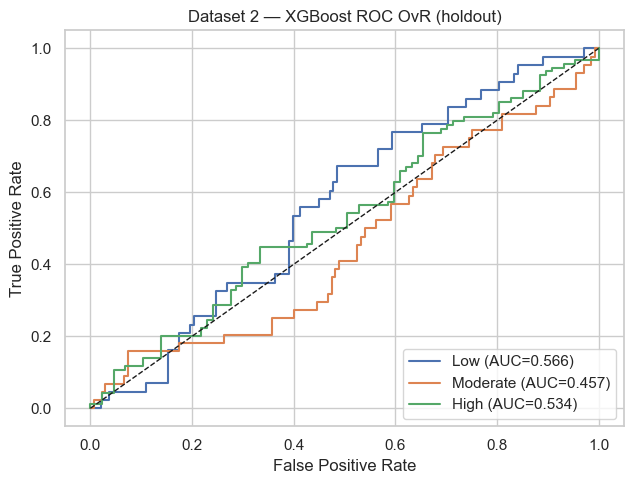

Saved model + metrics for Dataset 2


In [8]:
best_d2 = select_best_model(cv_summary_d2)
print("Best model (Dataset 2):", best_d2)

search_d2 = tune_and_fit_best(
    best_d2, X2_train, y2_train, n_iter=N_ITER_SEARCH, random_state=RANDOM_SEED
)
print("Best params:", search_d2.best_params_)

holdout_d2, pred_d2, proba_d2 = evaluate_holdout(search_d2.best_estimator_, X2_test, y2_test)
print("Holdout metrics:")
display(pd.Series(holdout_d2))
print(classification_report(y2_test, pred_d2, target_names=LABEL_ORDER, digits=3))

plot_confusion(
    y2_test.values,
    pred_d2,
    f"Dataset 2 — {best_d2} confusion matrix (holdout)",
    FIG_DIR / "dataset2_confusion.png",
)
plot_roc_ovr(
    y2_test.values,
    proba_d2,
    f"Dataset 2 — {best_d2} ROC OvR (holdout)",
    FIG_DIR / "dataset2_roc_ovr.png",
)

joblib.dump(search_d2.best_estimator_, RESULTS_DIR / "dataset2_best_model.joblib")
payload_d2 = {
    "dataset": "dataset2",
    "best_model": best_d2,
    "best_params": search_d2.best_params_,
    "cv_summary": cv_summary_d2.to_dict(orient="records"),
    "holdout_metrics": holdout_d2,
    "features": feats2,
}
(RESULTS_DIR / "dataset2_metrics.json").write_text(
    json.dumps(payload_d2, indent=2, default=str), encoding="utf-8"
)
print("Saved model + metrics for Dataset 2")

## B4. SHAP and LIME

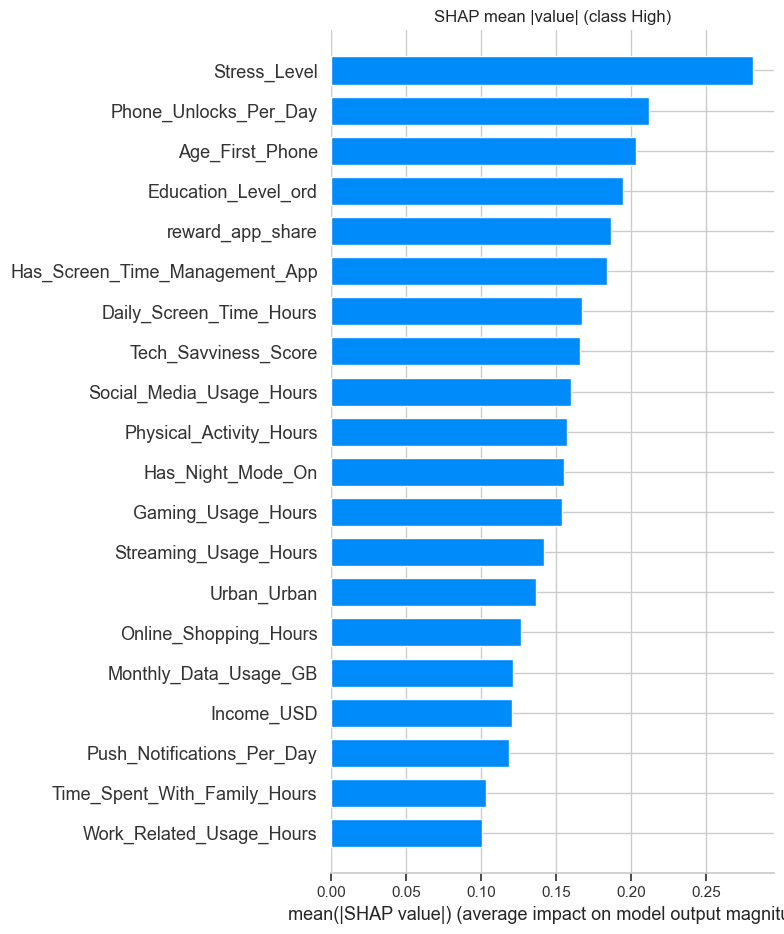

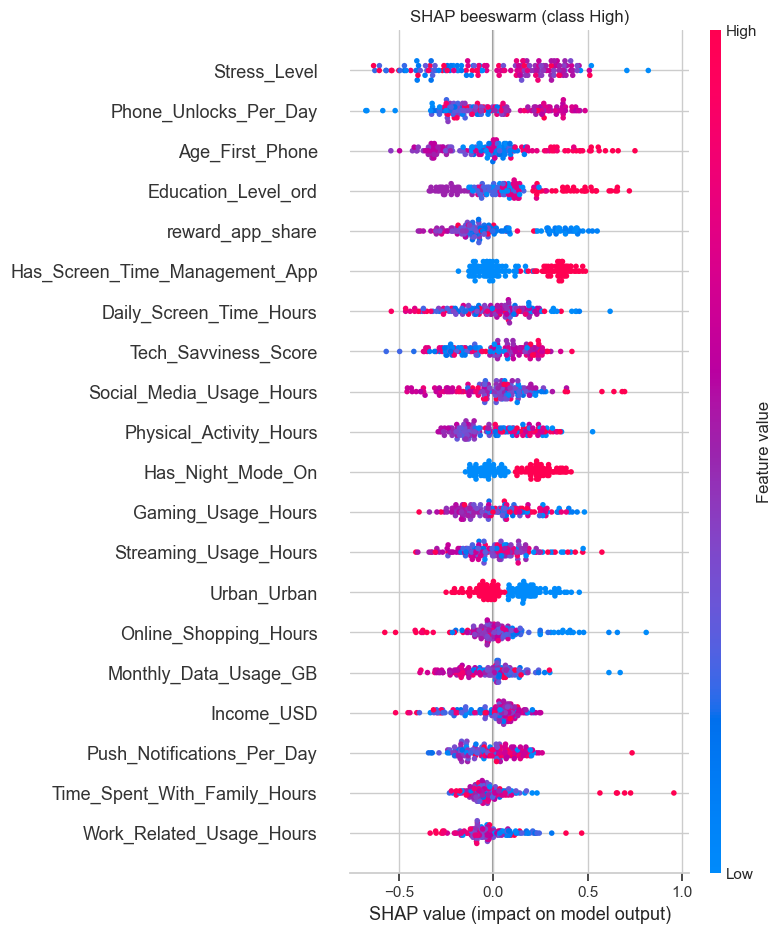

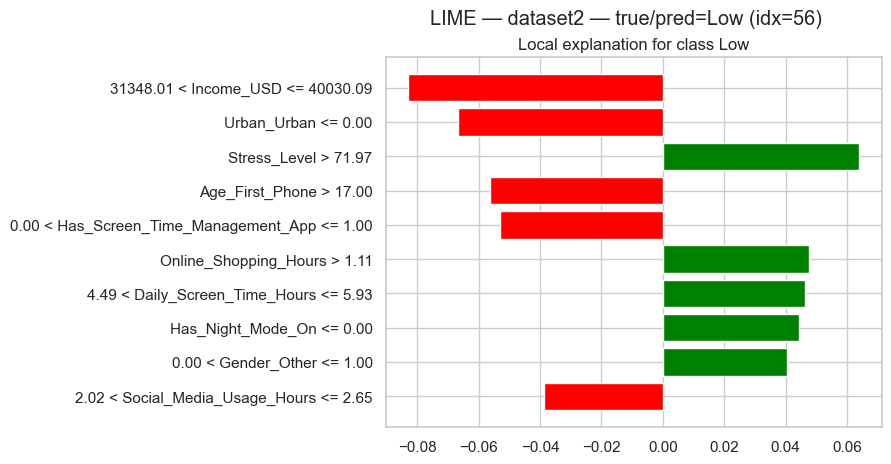

Saved LIME explanation: dataset2_lime_low.png


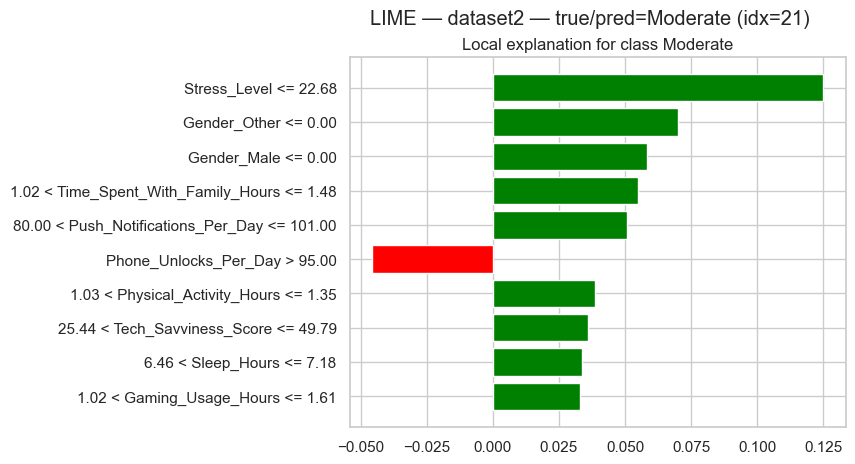

Saved LIME explanation: dataset2_lime_moderate.png


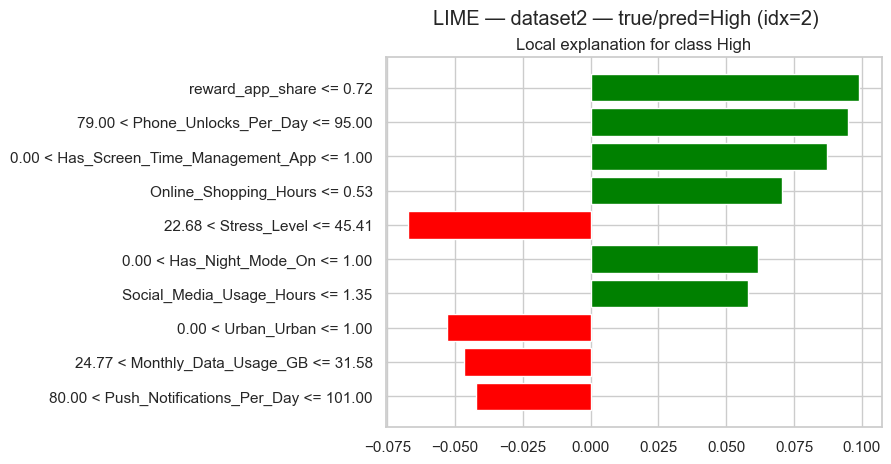

Saved LIME explanation: dataset2_lime_high.png


In [9]:
pipe_d2 = search_d2.best_estimator_
_ = run_shap(
    pipe_d2,
    best_d2,
    X2_train.values,
    X2_test.values,
    feats2,
    FIG_DIR / "dataset2",
    max_background=80,
    max_explain=150,
)

run_lime(
    pipe_d2,
    X2_train.values,
    X2_test.values,
    y2_test.values,
    pred_d2,
    feats2,
    FIG_DIR,
    dataset_tag="dataset2",
)

---
# Cross-dataset synthesis

| Topic | Dataset 1 | Dataset 2 |
|-------|-----------|-----------|
| Sample size | Larger (7500) | Smaller after 18–35 filter |
| Label origin | Severity / addiction_level mapping | Self-reported addiction (merged High+Severe) |
| Best model | See CV table above | See CV table above |
| XAI | Global SHAP + local LIME | Same protocol |

**Limitations**

- Labels are not identically defined across datasets — do not pool without harmonisation.
- SMOTE synthesises minority examples; metrics on holdout (no SMOTE) are the honest estimate.
- RBF-SVM nested tuning on Dataset 1 uses a stratified subsample for search tractability.
- KernelExplainer (if SVM/MLP wins) is approximate and subsampled.

**Next step for the paper:** move comparison tables and SHAP/LIME figures into Results / Discussion aligned to RQ1 (predictive accuracy) and RQ2 (feature importance).